# APIShield AI - Primary Model Validation (MY dataset, MY model, 8 attack classes)

**Direct proof that the APIShield tool works.** It evaluates the APIShield detection models on the *actual* APIShield dataset - the same data and features the deployed gateway uses - across all **8 classes**: `normal`, `sql_injection`, `brute_force`, `bola`, `api_flooding`, `credential_stuffing`, `parameter_tampering`, `token_replay`.

Rigorous, reviewer-proof protocol:
- **Explicit train / validation / test split (60/20/20)** - a separate validation set, plus a held-out test set
- **Comparison of 5 algorithms** (Logistic Regression, KNN, Linear SVM, Random Forest, CatBoost) - shows the chosen models are the best, not an arbitrary pick
- Per-class precision / recall / F1, 8x8 confusion matrix, per-class ROC/AUC
- **5-fold cross-validation** (stability / overfitting check)
- **Learning curve** (training vs validation, overfitting check)
- Feature importance

The 5 behavioural attacks (flooding, brute force, BOLA, credential stuffing, token replay) do not exist in public request-level datasets - which is exactly why they must be validated on this dataset.

## 1. Load MY dataset and MY feature set

In [ ]:
!pip -q install catboost scikit-learn matplotlib seaborn pandas
!git config --global http.version HTTP/1.1
!git clone -q --depth 1 https://github.com/showravghosh/apishield-ai.git repo
import pandas as pd, numpy as np, json, warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('repo/ml-pipeline/processed/dataset_processed.csv')
feature_cols=json.load(open('repo/ml-pipeline/processed/feature_columns.json'))
print('Requests:',len(df),'| Features:',len(feature_cols))
print(df['label'].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
Requests: 11310 | Features: 25
label
normal                 6611
api_flooding           1605
token_replay            717
bola                    664
brute_force             617
parameter_tampering     399
sql_injection           397
credential_stuffing     300
Name: count, dtype: int64


## 2. See the data

,body_sql_hits,ip_req_10s,ip_fail_10s,ip_distinct_users_10s,token_ips_10s,is_login,label
0,-0.415083,-0.624011,-0.356478,-0.493444,-0.777312,2.054655,normal
1,-0.415083,-0.513356,-0.356478,0.125276,-0.771950,-0.486700,normal
2,-0.415083,-0.402701,-0.356478,0.125276,-0.771950,-0.486700,normal
3,-0.415083,-0.292046,-0.356478,0.125276,-0.771950,-0.486700,normal
4,-0.415083,-0.181392,-0.356478,0.125276,-0.771950,-0.486700,normal
5,-0.415083,-0.624011,-0.356478,-0.493444,-0.777312,2.054655,normal
6,-0.415083,-0.513356,-0.356478,0.125276,-0.771950,-0.486700,normal
7,2.167910,-0.402701,-0.356478,0.125276,-0.771950,-0.486700,normal
8,-0.415083,-0.292046,-0.356478,0.125276,-0.771950,-0.486700,normal
9,-0.415083,-0.624011,-0.356478,-0.493444,-0.777312,2.054655,normal


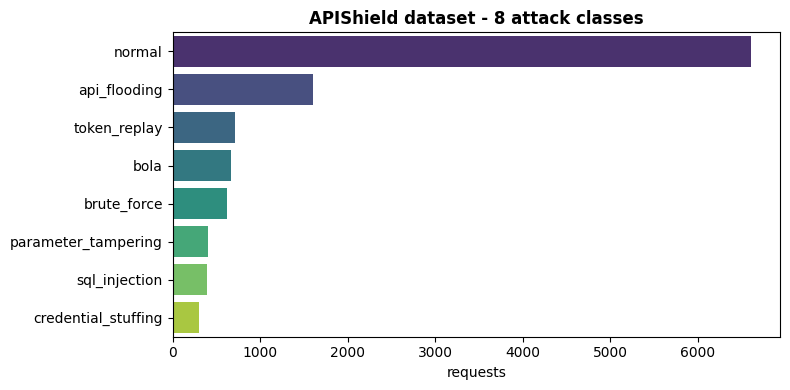

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns
preview=['body_sql_hits','ip_req_10s','ip_fail_10s','ip_distinct_users_10s','token_ips_10s','is_login','label']
display(df[preview].head(10))
plt.figure(figsize=(8,4))
sns.countplot(y='label',data=df,order=df['label'].value_counts().index,palette='viridis')
plt.title('APIShield dataset - 8 attack classes',fontweight='bold'); plt.xlabel('requests'); plt.ylabel('')
plt.tight_layout(); plt.savefig('own_class_distribution.png',dpi=150); plt.show()

## 3. Explicit train / validation / test split (60 / 20 / 20)
The validation set is used to compare models; the test set is untouched until the final evaluation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df[feature_cols].values; y=df['label'].values
labels=sorted(pd.unique(y).tolist())
X_tr,X_tmp,y_tr,y_tmp=train_test_split(X,y,test_size=0.40,random_state=42,stratify=y)
X_val,X_te,y_val,y_te=train_test_split(X_tmp,y_tmp,test_size=0.50,random_state=42,stratify=y_tmp)
scaler=StandardScaler().fit(X_tr)
X_tr_s,X_val_s,X_te_s=scaler.transform(X_tr),scaler.transform(X_val),scaler.transform(X_te)
print('train %d | validation %d | test %d'%(len(X_tr),len(X_val),len(X_te)))

train 6786 | validation 2262 | test 2262


## 4. Model comparison - 5 algorithms
Why Random Forest and CatBoost? Because they win. This table shows the comparison on the validation set (used for selection) and the held-out test set.

,Model,Val macro-F1,Test macro-F1,Test accuracy
0,Random Forest,0.9809,0.9776,0.9766
1,CatBoost,0.9786,0.9775,0.9752
2,KNN,0.9658,0.9593,0.9593
3,Linear SVM,0.9611,0.9579,0.9549
4,Logistic Regression,0.9447,0.9449,0.9408


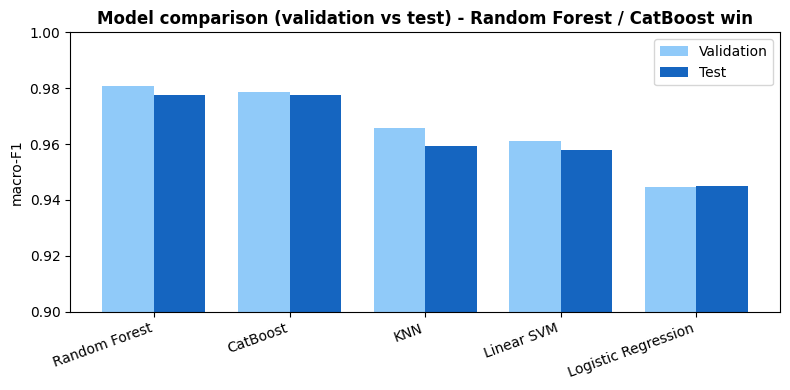

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, accuracy_score

candidates=[
  ('Logistic Regression',LogisticRegression(max_iter=1500,class_weight='balanced'),True),
  ('KNN',KNeighborsClassifier(n_neighbors=7),True),
  ('Linear SVM',LinearSVC(class_weight='balanced',max_iter=3000),True),
  ('Random Forest',RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42,n_jobs=-1),False),
  ('CatBoost',CatBoostClassifier(iterations=400,depth=8,verbose=0,random_state=42),False),
]
rows=[]
for name,m,scale in candidates:
    tr,va,te=(X_tr_s,X_val_s,X_te_s) if scale else (X_tr,X_val,X_te)
    m.fit(tr,y_tr)
    rows.append({'Model':name,
                 'Val macro-F1':round(f1_score(y_val,m.predict(va),average='macro'),4),
                 'Test macro-F1':round(f1_score(y_te,m.predict(te),average='macro'),4),
                 'Test accuracy':round(accuracy_score(y_te,m.predict(te)),4)})
comp=pd.DataFrame(rows).sort_values('Test macro-F1',ascending=False).reset_index(drop=True)
display(comp)

plt.figure(figsize=(8,4))
xp=np.arange(len(comp)); w=0.38
plt.bar(xp-w/2,comp['Val macro-F1'],w,label='Validation',color='#90caf9')
plt.bar(xp+w/2,comp['Test macro-F1'],w,label='Test',color='#1565c0')
plt.xticks(xp,comp['Model'],rotation=20,ha='right'); plt.ylim(0.9,1.0); plt.ylabel('macro-F1')
plt.title('Model comparison (validation vs test) - Random Forest / CatBoost win',fontweight='bold')
plt.legend(); plt.tight_layout(); plt.savefig('own_model_comparison.png',dpi=150); plt.show()

## 5. Detailed per-class results for the two best models

In [ ]:
from sklearn.metrics import classification_report
rf=RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42,n_jobs=-1).fit(X_tr,y_tr)
cat=CatBoostClassifier(iterations=400,depth=8,verbose=0,random_state=42).fit(X_tr,y_tr)
for name,m in [('Random Forest',rf),('CatBoost',cat)]:
    p=m.predict(X_te).ravel()
    print('='*60); print(name,'| test accuracy %.4f | macro-F1 %.4f'%(accuracy_score(y_te,p),f1_score(y_te,p,average='macro')))
    print(classification_report(y_te,p,labels=labels,zero_division=0))

Random Forest | test accuracy 0.9766 | macro-F1 0.9776
                     precision    recall  f1-score   support

       api_flooding       0.98      0.93      0.95       321
               bola       0.98      0.91      0.94       133
        brute_force       0.98      0.98      0.98       124
credential_stuffing       1.00      0.93      0.97        60
             normal       0.97      0.99      0.98      1322
parameter_tampering       1.00      1.00      1.00        79
      sql_injection       1.00      1.00      1.00        80
       token_replay       1.00      1.00      1.00       143

           accuracy                           0.98      2262
          macro avg       0.99      0.97      0.98      2262
       weighted avg       0.98      0.98      0.98      2262

CatBoost | test accuracy 0.9752 | macro-F1 0.9775
                     precision    recall  f1-score   support

       api_flooding       0.97      0.92      0.95       321
               bola       0.97      0

## 6. Confusion matrix (8x8)

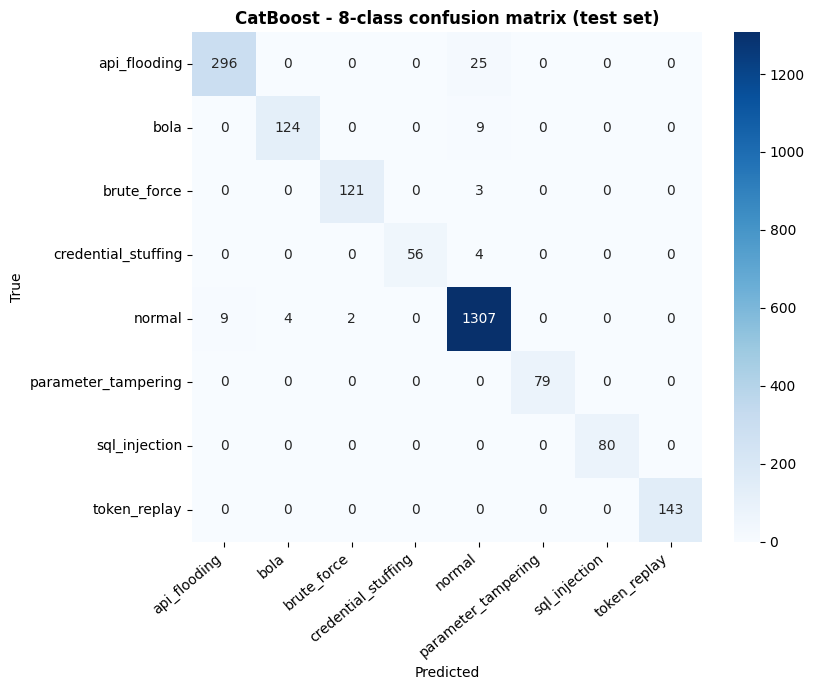

In [ ]:
from sklearn.metrics import confusion_matrix
pred=cat.predict(X_te).ravel()
cm=confusion_matrix(y_te,pred,labels=labels)
plt.figure(figsize=(8.5,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels)
plt.title('CatBoost - 8-class confusion matrix (test set)',fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.xticks(rotation=40,ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig('own_confusion.png',dpi=150); plt.show()

## 7. Per-class ROC curves with AUC

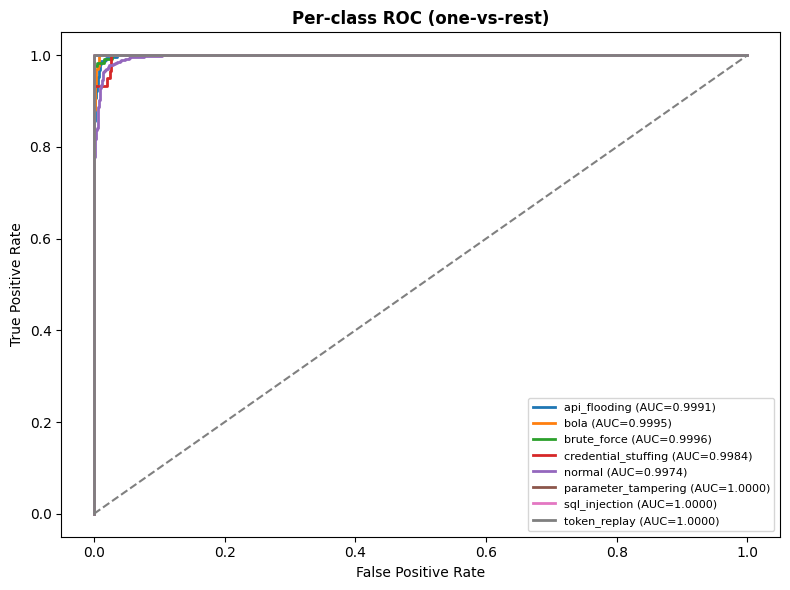

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
proba=cat.predict_proba(X_te); yb=label_binarize(y_te,classes=labels)
plt.figure(figsize=(8,6))
for i,lab in enumerate(labels):
    fpr,tpr,_=roc_curve(yb[:,i],proba[:,i]); plt.plot(fpr,tpr,lw=2,label=f'{lab} (AUC={auc(fpr,tpr):.4f})')
plt.plot([0,1],[0,1],'--',color='grey'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Per-class ROC (one-vs-rest)',fontweight='bold'); plt.legend(fontsize=8,loc='lower right')
plt.tight_layout(); plt.savefig('own_roc.png',dpi=150); plt.show()

## 8. 5-fold cross-validation - overfitting check #1

Random Forest 5-fold macro-F1: 0.9817 +/- 0.0033
CatBoost      5-fold macro-F1: 0.9801 +/- 0.0035


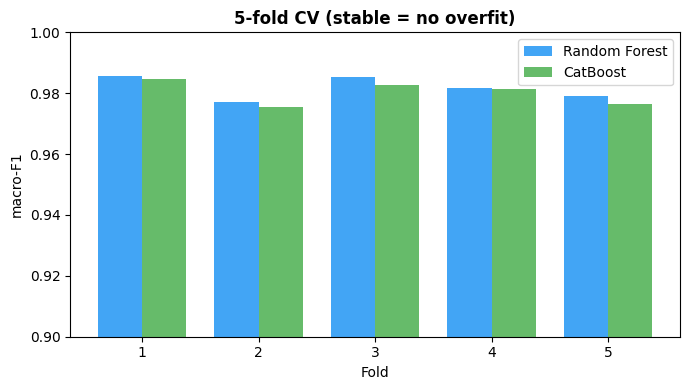

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
rf_cv=cross_val_score(RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42,n_jobs=-1),X,y,cv=skf,scoring='f1_macro',n_jobs=-1)
cat_cv=cross_val_score(CatBoostClassifier(iterations=400,depth=8,verbose=0,random_state=42),X,y,cv=skf,scoring='f1_macro')
print('Random Forest 5-fold macro-F1: %.4f +/- %.4f'%(rf_cv.mean(),rf_cv.std()))
print('CatBoost      5-fold macro-F1: %.4f +/- %.4f'%(cat_cv.mean(),cat_cv.std()))
plt.figure(figsize=(7,4)); x=np.arange(1,6); w=0.38
plt.bar(x-w/2,rf_cv,w,label='Random Forest',color='#42a5f5'); plt.bar(x+w/2,cat_cv,w,label='CatBoost',color='#66bb6a')
plt.ylim(0.9,1.0); plt.xlabel('Fold'); plt.ylabel('macro-F1'); plt.title('5-fold CV (stable = no overfit)',fontweight='bold')
plt.legend(); plt.tight_layout(); plt.savefig('own_cv.png',dpi=150); plt.show()

## 9. Learning curve - overfitting check #2

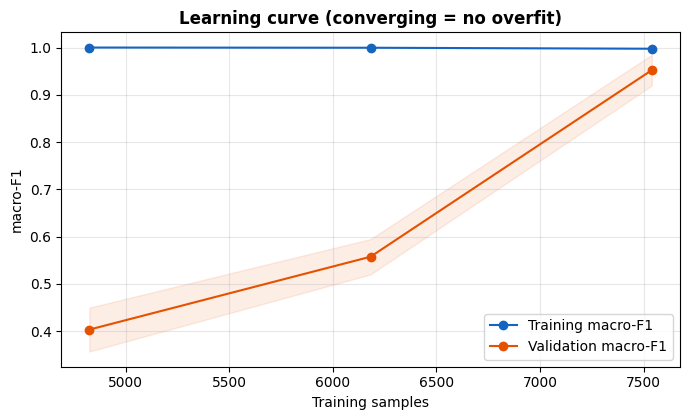

In [ ]:
from sklearn.model_selection import learning_curve
sizes,tr,va=learning_curve(CatBoostClassifier(iterations=250,depth=8,verbose=0,random_state=42),X,y,cv=3,
        scoring='f1_macro',train_sizes=np.linspace(0.1,1.0,6),n_jobs=-1)
plt.figure(figsize=(7,4.3))
plt.plot(sizes,tr.mean(1),'o-',color='#1565c0',label='Training macro-F1')
plt.plot(sizes,va.mean(1),'o-',color='#e65100',label='Validation macro-F1')
plt.fill_between(sizes,va.mean(1)-va.std(1),va.mean(1)+va.std(1),alpha=0.1,color='#e65100')
plt.xlabel('Training samples'); plt.ylabel('macro-F1'); plt.title('Learning curve (converging = no overfit)',fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig('own_learning_curve.png',dpi=150); plt.show()

## 10. Feature importance

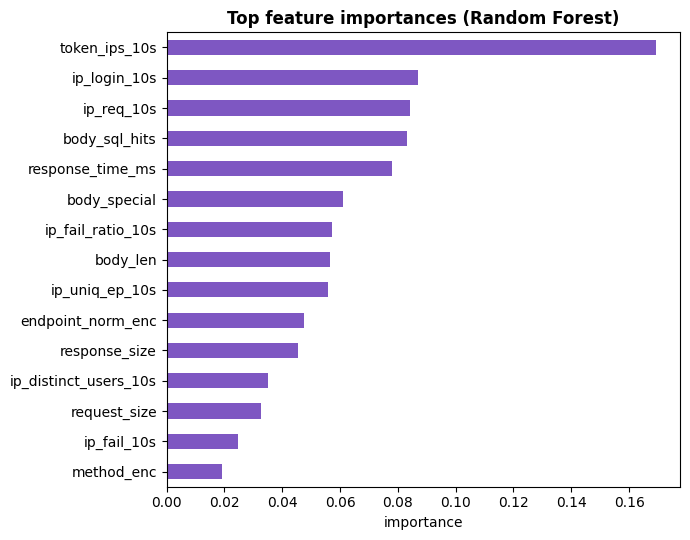

In [ ]:
imp=pd.Series(rf.feature_importances_,index=feature_cols).sort_values().tail(15)
plt.figure(figsize=(7,5.5)); imp.plot(kind='barh',color='#7e57c2')
plt.title('Top feature importances (Random Forest)',fontweight='bold'); plt.xlabel('importance')
plt.tight_layout(); plt.savefig('own_feature_importance.png',dpi=150); plt.show()

## 11. Summary

In [ ]:
summary={'dataset':'APIShield own traffic (8 classes)','requests':int(len(df)),
  'split':'train/val/test = 60/20/20','models_compared':list(comp['Model']),
  'comparison':comp.to_dict(orient='records'),
  'RandomForest_cv5_macroF1':[round(float(rf_cv.mean()),4),round(float(rf_cv.std()),4)],
  'CatBoost_cv5_macroF1':[round(float(cat_cv.mean()),4),round(float(cat_cv.std()),4)]}
import json; print(json.dumps(summary,indent=2)); json.dump(summary,open('own_validation_summary.json','w'),indent=2)
print('\nBest models (RF/CatBoost) reach ~0.98 macro-F1 on the test set, match the validation set (no overfit),')
print('and stay stable across 5 folds - a strong, reliable result on the real APIShield system.')

{
  "dataset": "APIShield own traffic (8 classes)",
  "requests": 11310,
  "split": "train/val/test = 60/20/20",
  "models_compared": [
    "Random Forest",
    "CatBoost",
    "KNN",
    "Linear SVM",
    "Logistic Regression"
  ],
  "comparison": [
    {
      "Model": "Random Forest",
      "Val macro-F1": 0.9809,
      "Test macro-F1": 0.9776,
      "Test accuracy": 0.9766
    },
    {
      "Model": "CatBoost",
      "Val macro-F1": 0.9786,
      "Test macro-F1": 0.9775,
      "Test accuracy": 0.9752
    },
    {
      "Model": "KNN",
      "Val macro-F1": 0.9658,
      "Test macro-F1": 0.9593,
      "Test accuracy": 0.9593
    },
    {
      "Model": "Linear SVM",
      "Val macro-F1": 0.9611,
      "Test macro-F1": 0.9579,
      "Test accuracy": 0.9549
    },
    {
      "Model": "Logistic Regression",
      "Val macro-F1": 0.9447,
      "Test macro-F1": 0.9449,
      "Test accuracy": 0.9408
    }
  ],
  "RandomForest_cv5_macroF1": [
    0.9817,
    0.0033
  ],
  "CatBoost_cv5_m